# Task 0 · Gradient boosting baseline

The team's reference model, built on the shared benchmark in [`forecast/`](forecast/). See [`TASK0_README.md`](TASK0_README.md) for the rules and the evaluation.

- **Day-ahead rule:** the forecast for day D is made at the end of day D-1. It uses load and weather up to D-1, nothing from day D.
- **Data processing choice:** `Config(weather_resampling=...)` sets how hourly weather becomes 15-min values, `"step"` or `"interpolate"`.
- **Output:** `evaluate.evaluate` prints the scores (nMAE, R²) of this run. Nothing is written to the leaderboard; to add a run there, call `evaluate.submit(...)` (see section 3).

Runtime ≈ 3 min (the first run also builds `cache/`), peak memory ≈ 6 GB.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

from forecast import Config, baselines, data, evaluate, features

config = Config(weather_resampling="step")  # "step" or "interpolate"
NAME = f"gbm_{config.weather_resampling}"  # label of this run (and its name if you submit it)
AUTHOR = "pengxuanHuang"
MODEL_PARAMS = dict(max_iter=300, learning_rate=0.1, categorical_features="from_dtype", random_state=0)

## 1. Standard features

In [2]:
df = features.build_features(config)
FEATURES = features.standard_features()
train, test = features.split(df, config)
print(f"{len(FEATURES)} features · train sample {len(train):,} rows · test {len(test):,} rows")
FEATURES

26 features · train sample 3,000,000 rows · test 12,471,135 rows


['temperature_1d',
 'temperature_day_mean_1d',
 'sunshine_1d',
 'humidity_1d',
 'wind_speed_1d',
 'sunshine_filled_1d',
 'quarter_hour',
 'weekday',
 'month',
 'kwh_lag_1d',
 'kwh_lag_7d',
 'is_treatment',
 'after_visit',
 'has_pv',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_Building_Type',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle']

## 2. Train

In [3]:
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train[FEATURES], train["kwh"])

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,300
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


## 3. Predict and evaluate

`evaluate.evaluate` scores every test row with the standard evaluation and only prints the result. To put a run on the shared leaderboard, uncomment the `evaluate.submit` line.

In [4]:
predictions = test[["Household_ID", "Timestamp"]].assign(prediction=model.predict(test[FEATURES]).clip(min=0))
print(f"{NAME}: nMAE % and R² per level")
display(evaluate.evaluate(predictions).round(3))

# evaluate.submit(predictions, NAME, AUTHOR,
#                 description=f"HistGradientBoosting, standard features, weather {config.weather_resampling}",
#                 config=config.to_dict(), params=MODEL_PARAMS)

gbm_step: nMAE % and R² per level


,nMAE,R2
portfolio_15min,11.611,0.904
portfolio_day,7.817,0.942
household_15min,62.541,0.416
household_day,21.510,0.819


# 3.1 Validation to optimize the hyperparameters of HGB

**Holdout:** the hyperparameters are compared on the **last two months before the test year** (2023-01-01 → 2023-02-28), training only on data before 2023-01-01 (a random 1M-row sample, to keep it fast). The test year itself is never used for tuning: otherwise the test score would be optimistic and no longer comparable with the leaderboard.

**Decision metric:** validation **portfolio nMAE per 15 min**, the same metric the leaderboard ranks by. The current `MODEL_PARAMS` are always one of the candidates, so the chosen set is at least as good on the holdout. The winner is then retrained on the full training data (3M rows before the test year) and scored on the test year next to the untuned model.

In [5]:
from forecast import tuning

N_CANDIDATES = 12  # random parameter sets to try (plus the current MODEL_PARAMS); ≈ 15 s each

fit_rows, val_rows = tuning.holdout_split(df, config, start="2023-01-01", sample=1_000_000)
val_days = val_rows["Timestamp"].dt.tz_convert("Europe/Berlin")
print(f"fit {len(fit_rows):,} rows before 2023-01-01 · validate {len(val_rows):,} rows "
      f"({val_days.min():%Y-%m-%d} → {val_days.max():%Y-%m-%d})")

candidates = tuning.random_candidates(N_CANDIDATES, seed=0, base=MODEL_PARAMS)
results = tuning.tune(fit_rows, val_rows, candidates, FEATURES)
params_table = pd.json_normalize(results["params"]).drop(columns=["categorical_features", "random_state"], errors="ignore")
pd.concat([results.drop(columns="params"), params_table], axis=1).round(3)

fit 1,000,000 rows before 2023-01-01 · validate 1,855,136 rows (2023-01-01 → 2023-02-28)
candidate  0: portfolio 15-min nMAE 11.02 % (30.7 s)
candidate  1: portfolio 15-min nMAE 11.72 % (49.5 s)
candidate  2: portfolio 15-min nMAE 11.64 % (29.3 s)
candidate  3: portfolio 15-min nMAE 11.55 % (103.0 s)
candidate  4: portfolio 15-min nMAE 11.27 % (55.4 s)
candidate  5: portfolio 15-min nMAE 11.10 % (106.2 s)
candidate  6: portfolio 15-min nMAE 11.02 % (42.4 s)
candidate  7: portfolio 15-min nMAE 10.92 % (24.0 s)
candidate  8: portfolio 15-min nMAE 11.14 % (29.9 s)
candidate  9: portfolio 15-min nMAE 11.36 % (27.4 s)
candidate 10: portfolio 15-min nMAE 11.08 % (53.4 s)
candidate 11: portfolio 15-min nMAE 11.59 % (47.8 s)
candidate 12: portfolio 15-min nMAE 11.51 % (60.8 s)


,candidate,portfolio_15min_nMAE,portfolio_15min_R2,portfolio_day_nMAE,household_15min_R2,fit_seconds,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,early_stopping
0,7,10.919,0.744,7.969,0.371,24.0,0.20,200,31,500,0.0,False
1,0,11.017,0.740,7.826,0.372,30.7,0.10,300,31,20,0.0,auto
2,6,11.020,0.741,8.339,0.373,42.4,0.20,400,31,500,1.0,False
3,10,11.083,0.738,8.264,0.374,53.4,0.10,400,127,20,0.1,False
4,5,11.098,0.734,8.268,0.377,106.2,0.05,800,127,20,0.1,False
5,8,11.142,0.735,8.151,0.375,29.9,0.10,200,63,100,0.1,False
6,4,11.273,0.730,8.457,0.376,55.4,0.10,400,127,100,1.0,False
7,9,11.358,0.722,7.879,0.362,27.4,0.05,200,31,20,0.0,False
8,12,11.513,0.711,8.332,0.364,60.8,0.20,400,127,500,0.1,False
9,3,11.546,0.718,8.739,0.371,103.0,0.10,800,127,100,1.0,False


# Uncertainty and procurement decisions

In [9]:
quantile_predictions = {}
for q in (0.1, 0.5, 0.75, 0.9):
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        max_iter=300,
        learning_rate=0.1,
        categorical_features="from_dtype",
        random_state=0,
    )
    model.fit(fit_rows[FEATURES], fit_rows["kwh"])
    quantile_predictions[q] = model.predict(val_rows[FEATURES]).clip(min=0)

lower, median, upper = (
    quantile_predictions[0.1],
    quantile_predictions[0.5],
    quantile_predictions[0.9],
)
coverage_80 = ((val_rows["kwh"] >= lower) & (val_rows["kwh"] <= upper)).mean()
mean_width = (upper - lower).mean()
print(f"80% interval coverage: {coverage_80:.1%}; mean width: {mean_width:.3f} kWh")

80% interval coverage: 78.1%; mean width: 0.774 kWh


In [11]:
check = val_rows[["quarter_hour", "has_pv"]].copy()
check["covered"] = (
    (val_rows["kwh"].to_numpy() >= lower)
    & (val_rows["kwh"].to_numpy() <= upper)
)
check["width"] = upper - lower

by_time = check.groupby("quarter_hour").agg(
    rows=("width", "size"),
    coverage=("covered", "mean"),
    mean_width=("width", "mean"),
)
by_pv = check.groupby("has_pv", dropna=False).agg(
    rows=("width", "size"),
    coverage=("covered", "mean"),
    mean_width=("width", "mean"),
)

display(by_time.sort_values("mean_width", ascending=False).head(10).round(3))
display(by_pv.round(3))

,rows,coverage,mean_width
quarter_hour,,,
10,19326,0.800,0.867
82,19326,0.812,0.866
81,19326,0.811,0.864
8,19326,0.802,0.863
0,19286,0.800,0.862
83,19326,0.818,0.859
84,19326,0.812,0.857
80,19326,0.811,0.856
9,19326,0.800,0.852


,rows,coverage,mean_width
has_pv,,,
0.0,507436,0.790,0.812
1.0,560980,0.759,0.762
NaN,786720,0.790,0.759


In [12]:
portfolio_val = pd.DataFrame(
    {
        "actual": val_rows["kwh"].to_numpy(),
        "q50": median,
        "q75": quantile_predictions[0.75],
    },
    index=val_rows["Timestamp"],
).groupby(level=0).sum()

under_cost, over_cost = 3.0, 1.0

for forecast in ("q50", "q75"):
    shortfall = (portfolio_val["actual"] - portfolio_val[forecast]).clip(lower=0)
    surplus = (portfolio_val[forecast] - portfolio_val["actual"]).clip(lower=0)
    mean_cost = (under_cost * shortfall + over_cost * surplus).mean()
    print(f"{forecast}: mean assumed cost per 15 min = {mean_cost:.2f}")

q50: mean assumed cost per 15 min = 79.08
q75: mean assumed cost per 15 min = 52.99


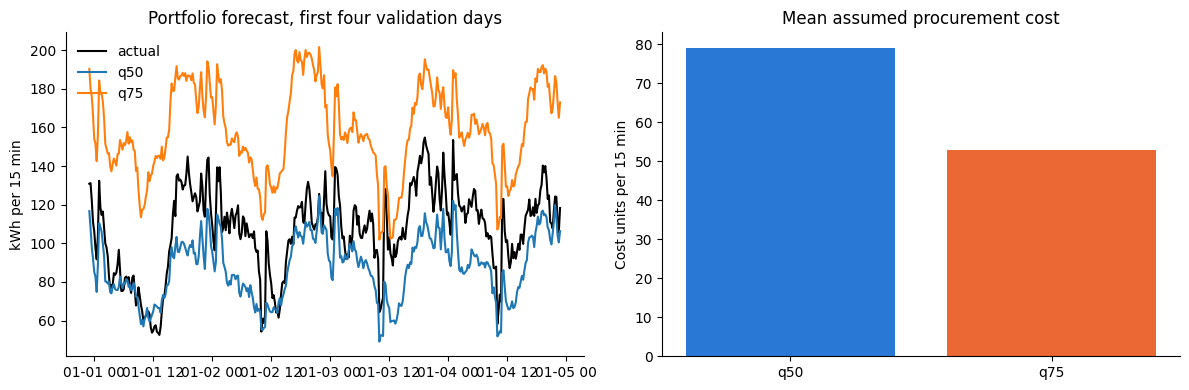

In [15]:
costs = {}
for name in ("q50", "q75"):
    shortfall = (portfolio_val["actual"] - portfolio_val[name]).clip(lower=0)
    surplus = (portfolio_val[name] - portfolio_val["actual"]).clip(lower=0)
    costs[name] = (3.0 * shortfall + surplus).mean()

view = portfolio_val.iloc[:96 * 4]  # first four validation days

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(view.index, view["actual"], color="black", label="actual")
axes[0].plot(view.index, view["q50"], label="q50")
axes[0].plot(view.index, view["q75"], label="q75")
axes[0].set(title="Portfolio forecast, first four validation days",
            ylabel="kWh per 15 min")
axes[0].legend(frameon=False)

axes[1].bar(["q50", "q75"], [costs["q50"], costs["q75"]],
            color=["#2a78d6", "#eb6834"])
axes[1].set(title="Mean assumed procurement cost",
            ylabel="Cost units per 15 min")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

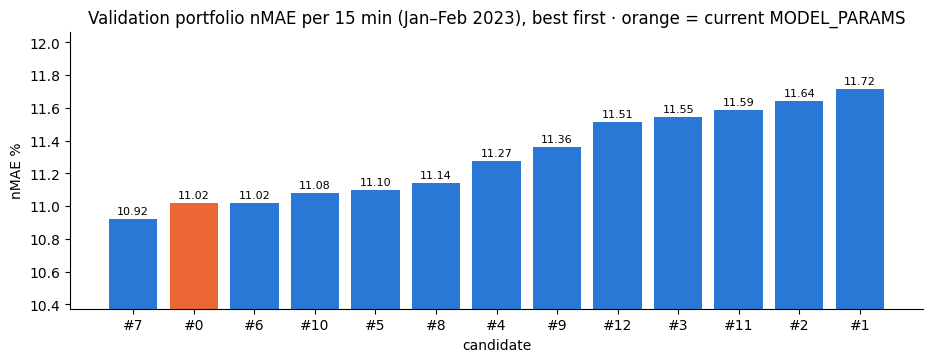

In [14]:
# Validation score per candidate (lower is better); the current MODEL_PARAMS are candidate 0
x = np.arange(len(results))
fig, ax = plt.subplots(figsize=(11, 3.6))
bars = ax.bar(x, results["portfolio_15min_nMAE"],
              color=np.where(results["candidate"] == 0, "#eb6834", "#2a78d6"))
ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x, [f"#{c}" for c in results["candidate"]])
ax.set(title="Validation portfolio nMAE per 15 min (Jan–Feb 2023), best first · orange = current MODEL_PARAMS",
       xlabel="candidate", ylabel="nMAE %",
       ylim=(results["portfolio_15min_nMAE"].min() * 0.95, results["portfolio_15min_nMAE"].max() * 1.03))
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
# Retrain the best candidate on the full training data and score it on the test year
BEST_PARAMS = results.loc[0, "params"]
print("best parameters:", {k: v for k, v in BEST_PARAMS.items() if k not in ("categorical_features", "random_state")})

model_tuned = HistGradientBoostingRegressor(**BEST_PARAMS).fit(train[FEATURES], train["kwh"])
predictions_tuned = test[["Household_ID", "Timestamp"]].assign(
    prediction=model_tuned.predict(test[FEATURES]).clip(min=0))

pd.concat({NAME: evaluate.evaluate(predictions), f"{NAME}_tuned": evaluate.evaluate(predictions_tuned)},
          axis=1).round(3)

# evaluate.submit(predictions_tuned, f"{NAME}_tuned", AUTHOR,
#                 description="HistGradientBoosting tuned on Jan-Feb 2023 holdout, standard features",
#                 config=config.to_dict(), params=BEST_PARAMS)

## 4. Reference baselines

Naive forecasts every model should beat, scored the same way (printed only).

In [ ]:
# All forecasts of this run, used by the comparisons below
runs = {
    NAME: predictions,
    f"{NAME}_tuned": predictions_tuned,                 # best parameters from 3.1
    "naive_lag_1d": baselines.naive(df, "kwh_lag_1d"),  # same 15 min yesterday
    "naive_lag_7d": baselines.naive(df, "kwh_lag_7d"),  # same 15 min one week ago
}
scores = {name: evaluate.evaluate(p) for name, p in runs.items()}
for name in ("naive_lag_1d", "naive_lag_7d"):
    print(f"{name}: nMAE % and R² per level")
    display(scores[name].round(3))

## 5. Comparison of this run

Side by side, and the daily portfolio energy over the test winter. `evaluate.leaderboard()` still shows the shared leaderboard (submitted runs only).

In [ ]:
pd.concat({name: s.stack() for name, s in scores.items()}, axis=1).T.round(3)

portfolio_15min                        portfolio_day            \
                         MAE    RMSE    nMAE   bias           MAE      RMSE   
gbm_step              11.654  16.466  11.611  0.929       752.471  1113.287   
naive_lag_1d          13.462  19.246  13.413  0.276       760.878  1148.258   
naive_lag_7d          20.529  30.043  20.454  0.602      1628.862  2459.917   

                            household_15min                        \
                nMAE   bias             MAE   RMSE    nMAE   bias   
gbm_step       7.817  0.927           0.175  0.287  62.541  0.929   
naive_lag_1d   7.904  0.198           0.194  0.371  69.229  0.276   
naive_lag_7d  16.921  0.521           0.205  0.380  73.035  0.602   

             household_day                         
                       MAE    RMSE    nMAE   bias  
gbm_step             5.792   8.902  21.510  0.927  
naive_lag_1d         5.476   9.234  20.337  0.198  
naive_lag_7d         7.871  12.724  29.228  0.521

In [ ]:
truth = data.ground_truth()
COLORS = ["#2a78d6", "#1baf7a", "#eb6834", "#eda100"]  # one per entry in `runs`, same order

# Daily portfolio energy: actual vs the forecasts of this run (partial last test day left out)
day = truth["Timestamp"].dt.tz_convert("Europe/Berlin").dt.date
daily = pd.DataFrame({"actual": truth["kwh"].groupby(day).sum()})
for name, p in runs.items():
    aligned = truth[["Household_ID", "Timestamp"]].merge(p, on=["Household_ID", "Timestamp"], how="left")
    daily[name] = aligned["prediction"].groupby(day.to_numpy()).sum()
daily = daily[daily["actual"] > 0.5 * daily["actual"].median()]
daily.index = pd.to_datetime(daily.index)
winter = daily.loc["2023-11-01":]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(winter.index, winter["actual"], color="#0b0b0b", linewidth=1.8, label="actual")
for name, color in list(zip(runs, COLORS))[:3]:  # the model, the tuned model and yesterday's value
    ax.plot(winter.index, winter[name], color=color, linewidth=1.2, label=name)
ax.set(title="Daily portfolio energy, test winter", ylabel="kWh per day")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=4)
plt.show()

## 6. R² score

R² = 1 − Σ(actual − predicted)² / Σ(actual − mean actual)²: the share of the variation in consumption that the forecast explains. 1 is perfect, 0 is no better than always predicting the average, and below 0 is worse than that.

The bar chart compares R² of this model and the naive baselines at all four evaluation levels. The scatter plots show predicted vs actual portfolio consumption for this model: the closer the points lie to the dashed 1:1 line, the higher R².

In [ ]:
r2 = pd.DataFrame({name: s["R2"] for name, s in scores.items()})

# Portfolio sums of this model, for predicted-vs-actual
m = truth.merge(predictions, on=["Household_ID", "Timestamp"], how="left")
portfolio_15min = m.groupby("Timestamp")[["kwh", "prediction"]].sum()
portfolio_day = m.groupby(day.to_numpy())[["kwh", "prediction"]].sum()
portfolio_day = portfolio_day[portfolio_day["kwh"] > 0.5 * portfolio_day["kwh"].median()]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), width_ratios=[1.4, 1, 1])

# 1) R² per level and forecast
x = np.arange(len(r2.index))
width = 0.8 / len(r2.columns)
for i, (name, color) in enumerate(zip(r2.columns, COLORS)):
    bars = axes[0].bar(x + (i - (len(r2.columns) - 1) / 2) * width, r2[name], width * 0.92, color=color, label=name)
    axes[0].bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
axes[0].set(xticks=x, xticklabels=[lvl.replace("_", "\n") for lvl in r2.index], ylabel="R²",
            title="R² by level (1 = perfect, 0 = as good as the mean)")
axes[0].axhline(0, color="#8a8984", linewidth=0.8)
axes[0].set_ylim(top=max(1.0, r2.max().max()) * 1.18)  # room for the legend above the bars
axes[0].legend(frameon=False, fontsize=8, ncol=len(r2.columns), loc="upper center")

# 2) and 3) predicted vs actual, with the 1:1 line
panels = [("Portfolio · 15 min", "portfolio_15min", portfolio_15min),
          ("Portfolio · day", "portfolio_day", portfolio_day)]
for ax, (title, level, t) in zip(axes[1:], panels):
    many = len(t) > 1000
    ax.scatter(t["kwh"], t["prediction"], s=4 if many else 14, alpha=0.25 if many else 0.6,
               color=COLORS[0], linewidths=0)
    hi = max(t["kwh"].max(), t["prediction"].max()) * 1.03
    ax.plot([0, hi], [0, hi], color="#52514e", linewidth=1, linestyle="--")
    ax.set(xlim=(0, hi), ylim=(0, hi), aspect="equal", xlabel="actual (kWh)", ylabel="predicted (kWh)",
           title=f"{title}: R² = {r2.loc[level, NAME]:.3f}")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

KeyError: 'R2'